# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Muyassaroh
- **Email:** muyassaroh9691@gmail.com
- **ID Dicoding:** CDCC180D6X2506

## Menentukan Pertanyaan Bisnis

## Menentukan Pertanyaan Bisnis

 **1. Apakah durasi pengiriman berpengaruh terhadap skor review pelanggan??**
- **Specific:** Fokus pada hubungan antara delivery_days dan review_score.
  - **Measurable:** Diukur dari selisih hari antara order_purchase_timestamp dan order_delivered_customer_date.
  - **Action-Oriented:** Hasilnya dapat digunakan untuk menetapkan SLA pengiriman.
  - **Relevant:** Kepuasan pelanggan (review) adalah indikator kualitas layanan e-commerce.
  - **Time-bound:** Data mencakup seluruh periode dataset 2016–2018.

**2. Kategori produk apa yang memiliki rata-rata review score tertinggi dan terendah di platform Olist selama periode 2017–2018, dan berapa selisihnya?**
- **Specific:** Fokus pada perbandingan rata-rata review score antar kategori produk.
- **Measurable:** Dihitung dari rata-rata `review_score` (skala 1–5) per kategori.
- **Action-Oriented:** Kategori dengan review rendah menjadi prioritas perbaikan kualitas produk atau seleksi seller.
- **Relevant:** Customer satisfaction langsung memengaruhi repeat purchase dan reputasi platform.
- **Time-bound:** Dibatasi pada periode 2017–2018.


**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** xxx
- **Pertanyaan 2:** xxx
- ...

## Import Semua Packages/Library yang Digunakan

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Pengaturan tampilan plot
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("Semua library berhasil diimport!")


Semua library berhasil diimport!


## Data Wrangling

## Gathering Data

In [20]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall('.')

for root, dirs, filenames in os.walk('.'):
    for f in filenames:
        if f.endswith('.csv'):
            print(os.path.join(root, f))

Saving E-commerce-public-dataset.zip to E-commerce-public-dataset.zip
./sellers_dataset.csv
./order_items_dataset.csv
./order_reviews_dataset.csv
./products_dataset.csv
./geolocation_dataset.csv
./order_payments_dataset.csv
./orders_dataset.csv
./customers_dataset.csv
./product_category_name_translation.csv
./E-Commerce Public Dataset/sellers_dataset.csv
./E-Commerce Public Dataset/order_items_dataset.csv
./E-Commerce Public Dataset/order_reviews_dataset.csv
./E-Commerce Public Dataset/products_dataset.csv
./E-Commerce Public Dataset/geolocation_dataset.csv
./E-Commerce Public Dataset/order_payments_dataset.csv
./E-Commerce Public Dataset/orders_dataset.csv
./E-Commerce Public Dataset/customers_dataset.csv
./E-Commerce Public Dataset/product_category_name_translation.csv
./sample_data/california_housing_test.csv
./sample_data/mnist_train_small.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_train.csv


#### Load df ...

In [23]:
BASE = './E-Commerce Public Dataset/'

orders_df         = pd.read_csv(BASE + 'orders_dataset.csv')
order_items_df    = pd.read_csv(BASE + 'order_items_dataset.csv')
order_payments_df = pd.read_csv(BASE + 'order_payments_dataset.csv')
order_reviews_df  = pd.read_csv(BASE + 'order_reviews_dataset.csv')
customers_df      = pd.read_csv(BASE + 'customers_dataset.csv')
products_df       = pd.read_csv(BASE + 'products_dataset.csv')
sellers_df        = pd.read_csv(BASE + 'sellers_dataset.csv')
translation_df    = pd.read_csv(BASE + 'product_category_name_translation.csv')

print('Shape masing-masing dataset:')
datasets = {
    'orders': orders_df,
    'order_items': order_items_df,
    'order_payments': order_payments_df,
    'order_reviews': order_reviews_df,
    'customers': customers_df,
    'products': products_df,
    'sellers': sellers_df,
    'translation': translation_df,
}
for name, df in datasets.items():
    print(f'  {name}: {df.shape}')

Shape masing-masing dataset:
  orders: (99441, 8)
  order_items: (112650, 7)
  order_payments: (103886, 5)
  order_reviews: (99224, 7)
  customers: (99441, 5)
  products: (32951, 9)
  sellers: (3095, 4)
  translation: (71, 2)


**Insight — Gathering Data:**
- Terdapat 8 tabel yang saling berelasi membentuk skema bintang (star schema).
- Tabel utama adalah `orders_dataset` dengan 99.441 baris yang menjadi pusat relasi ke tabel lainnya.
- Dataset `order_reviews` memiliki kolom komentar teks yang kaya, namun banyak nilainya kosong.
- `product_category_name_translation` berfungsi sebagai lookup table untuk menerjemahkan nama kategori dari Portugis ke Inggris.


### Assessing Data

Mengidentifikasi masalah kualitas data sebelum dilakukan analisis.

In [25]:
print('=== Missing Values: orders_df ===')
print(orders_df.isnull().sum())
print()
print('=== Missing Values: products_df ===')
print(products_df.isnull().sum())
print()
print('=== Missing Values: order_reviews_df ===')
print(order_reviews_df.isnull().sum())

print('=== Tipe Data: orders_df ===')
print(orders_df.dtypes)
print()
print('Kolom timestamp berikut masih bertipe object, seharusnya datetime:')
print([c for c in orders_df.columns if 'date' in c or 'timestamp' in c])

print('Jumlah baris duplikat per dataset:')
for name, df in datasets.items():
    print(f'  {name}: {df.duplicated().sum()} duplikat')

=== Missing Values: orders_df ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== Missing Values: products_df ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

=== Missing Values: order_reviews_df ===
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
=== Tip

**Steps to Take:**
- `orders_df`: Kolom `order_delivered_customer_date` memiliki 2.965 missing value → akan difilter karena analisis hanya pada pesanan *delivered*.
- `products_df`: Kolom `product_category_name` memiliki 610 missing value → akan diisi `'unknown'` setelah merge dengan tabel terjemahan.
- `order_reviews_df`: Kolom komentar banyak null → wajar karena pelanggan tidak wajib mengisi komentar, tidak perlu ditangani.
- Semua kolom timestamp pada `orders_df` harus dikonversi ke tipe `datetime` menggunakan `pd.to_datetime()`.

**Insight:**
- Ditemukan 2 permasalahan utama: **missing value** (pada kolom tanggal pengiriman dan kategori produk) dan **tipe data tidak sesuai** (kolom timestamp masih object).
- Tidak ditemukan data duplikat pada seluruh dataset.

### Cleaning Data

Memperbaiki masalah yang ditemukan pada tahap Assessing Data.

In [28]:
# 1. Konversi tipe data timestamp
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Filter pesanan delivered & hapus missing tanggal pengiriman
delivered_df = orders_df[orders_df['order_status'] == 'delivered'].copy()
delivered_df = delivered_df.dropna(subset=['order_delivered_customer_date'])

# 3. Feature engineering
delivered_df['delivery_days'] = (
    delivered_df['order_delivered_customer_date'] - delivered_df['order_purchase_timestamp']
).dt.days
delivered_df['month'] = delivered_df['order_purchase_timestamp'].dt.to_period('M').astype(str)
delivered_df['year']  = delivered_df['order_purchase_timestamp'].dt.year

# 4. Merge items + products + terjemahan & isi missing category
items_full = order_items_df.merge(
    products_df[['product_id', 'product_category_name']], on='product_id', how='left'
)
items_full = items_full.merge(translation_df, on='product_category_name', how='left')
items_full['product_category_name_english'] = (
    items_full['product_category_name_english'].fillna('unknown')
)
items_full['revenue'] = items_full['price'] + items_full['freight_value']

# 5. Dataset final untuk analisis
rev_df = delivered_df.merge(
    items_full[['order_id', 'product_category_name_english', 'price', 'freight_value', 'revenue']],
    on='order_id', how='left'
)
delivery_review_df = delivered_df.merge(
    order_reviews_df[['order_id', 'review_score']], on='order_id', how='left'
).dropna(subset=['review_score', 'delivery_days'])

print(f'✅ delivered_df      : {len(delivered_df):,} baris')
print(f'✅ rev_df            : {rev_df.shape}')
print(f'✅ delivery_review_df: {delivery_review_df.shape}')

✅ delivered_df      : 96,470 baris
✅ rev_df            : (110189, 15)
✅ delivery_review_df: (96353, 12)


**Insight — Cleaning Data:**
- Missing value pada `product_category_name` (610 baris) diisi dengan label `'unknown'` sehingga tidak ada data yang hilang saat merge.
- DataFrame utama untuk analisis (`delivered_df`) hanya mencakup order berstatus **delivered** (96.470 baris) agar analisis revenue dan review score valid.
- Kolom `total_revenue` dibuat dengan menjumlahkan `price + freight_value` per item order.


## Exploratory Data Analysis (EDA)

### Eksplorasi 1: Tren Revenue Bulanan (2017–2018)

In [30]:
# Q1: Revenue per kategori
cat_revenue = (
    rev_df.groupby('product_category_name_english')['revenue']
    .sum().sort_values(ascending=False)
)
print('=== Top 10 Kategori berdasarkan Total Revenue ===')
print(cat_revenue.head(10).apply(lambda x: f'R$ {x:,.2f}'))

# Tren bulanan
monthly_rev = (
    rev_df.groupby('month')['revenue']
    .sum().reset_index().sort_values('month')
)
monthly_rev = monthly_rev[monthly_rev['month'] >= '2017-01']
print('\n=== Revenue Bulanan 2017–2018 (10 terakhir) ===')
print(monthly_rev.tail(10).to_string(index=False))

# Q2: Durasi pengiriman vs review
avg_delivery = delivery_review_df.groupby('review_score')['delivery_days'].agg(['mean','median','count']).round(1)
avg_delivery.columns = ['Rata-rata (hari)', 'Median (hari)', 'Jumlah Pesanan']
print('\n=== Durasi Pengiriman per Skor Review ===')
print(avg_delivery)

print('\n=== Korelasi Durasi Pengiriman & Skor Review ===')
print(delivery_review_df[['delivery_days', 'review_score']].corr().round(3))

=== Top 10 Kategori berdasarkan Total Revenue ===
product_category_name_english
health_beauty            R$ 1,412,089.53
watches_gifts            R$ 1,264,016.98
bed_bath_table           R$ 1,225,209.26
sports_leisure           R$ 1,118,062.91
computers_accessories    R$ 1,032,603.65
furniture_decor            R$ 880,329.92
housewares                 R$ 758,392.25
cool_stuff                 R$ 691,680.89
auto                       R$ 669,319.92
garden_tools               R$ 567,145.68
Name: revenue, dtype: object

=== Revenue Bulanan 2017–2018 (10 terakhir) ===
  month    revenue
2017-11 1153229.37
2017-12  843078.29
2018-01 1077887.46
2018-02  966168.41
2018-03 1120598.24
2018-04 1132878.93
2018-05 1128774.52
2018-06 1011448.96
2018-07 1027286.52
2018-08  985491.64

=== Durasi Pengiriman per Skor Review ===
              Rata-rata (hari)  Median (hari)  Jumlah Pesanan
review_score                                                 
1.0                       20.8           16.0           

## Visualization & Explanatory Analysis

### Pertanyaan 1: Apakah durasi pengiriman berpengaruh terhadap skor review pelanggan??

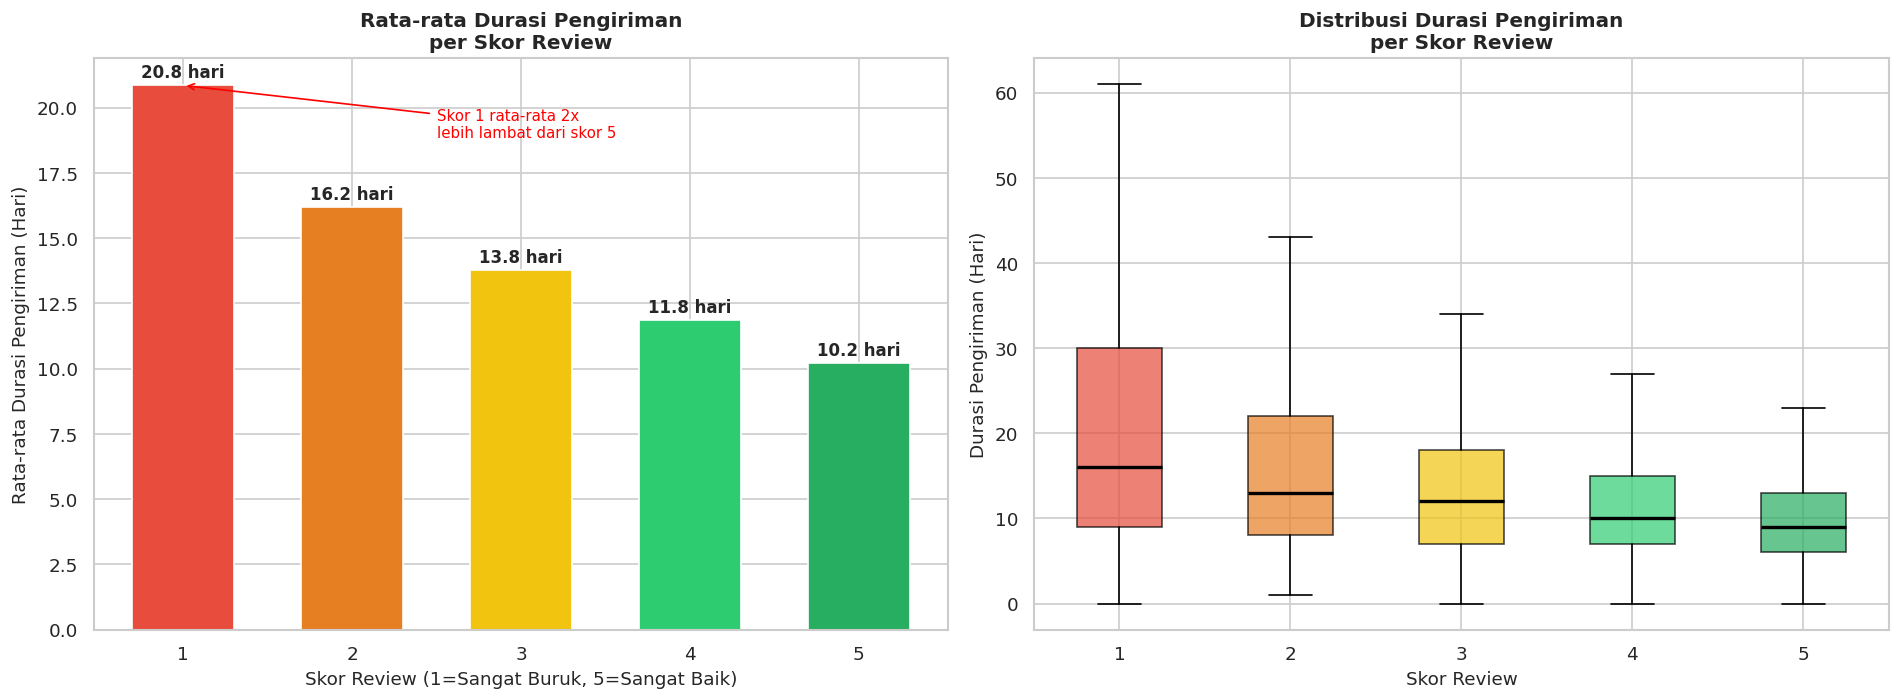

In [34]:
palette = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart rata-rata delivery days
avg_days = delivery_review_df.groupby('review_score')['delivery_days'].mean()
bars = axes[0].bar(avg_days.index, avg_days.values,
                   color=palette, edgecolor='white', width=0.6)
axes[0].set_xlabel('Skor Review (1=Sangat Buruk, 5=Sangat Baik)', fontsize=11)
axes[0].set_ylabel('Rata-rata Durasi Pengiriman (Hari)', fontsize=11)
axes[0].set_title('Rata-rata Durasi Pengiriman\nper Skor Review', fontsize=12, fontweight='bold')
axes[0].set_xticks([1,2,3,4,5])
for bar, val in zip(bars, avg_days.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f} hari', ha='center', fontsize=10, fontweight='bold')
axes[0].annotate('Skor 1 rata-rata 2x\nlebih lambat dari skor 5',
                  xy=(1, avg_days[1]), xytext=(2.5, avg_days[1]-2),
                  arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')

# Box plot distribusi
groups = [delivery_review_df[delivery_review_df['review_score']==s]['delivery_days'].dropna()
          for s in [1,2,3,4,5]]
bp = axes[1].boxplot(groups, labels=[1,2,3,4,5], patch_artist=True,
                     medianprops=dict(color='black', linewidth=2), showfliers=False)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Skor Review', fontsize=11)
axes[1].set_ylabel('Durasi Pengiriman (Hari)', fontsize=11)
axes[1].set_title('Distribusi Durasi Pengiriman\nper Skor Review', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Pertanyaan 2: Kategori produk apa yang memiliki review score tertinggi dan terendah?

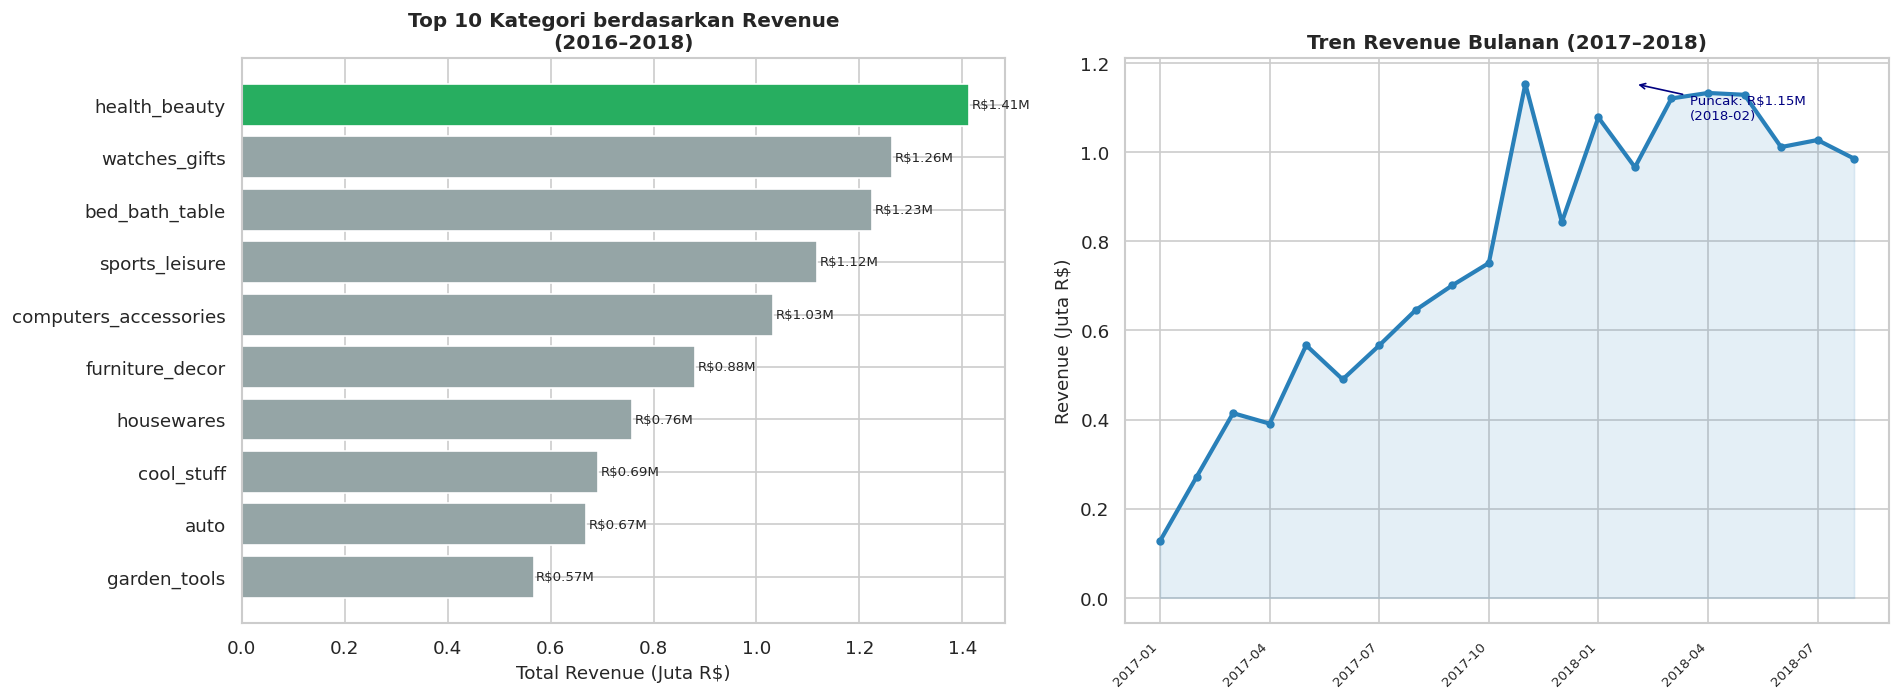

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 10 kategori
top10  = cat_revenue.head(10)
colors = ['#27ae60' if i == 0 else '#95a5a6' for i in range(10)]
bars   = axes[0].barh(top10.index[::-1], top10.values[::-1]/1e6,
                       color=colors[::-1], edgecolor='white')
axes[0].set_xlabel('Total Revenue (Juta R$)', fontsize=11)
axes[0].set_title('Top 10 Kategori berdasarkan Revenue\n(2016–2018)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, top10.values[::-1]):
    axes[0].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f'R${val/1e6:.2f}M', va='center', fontsize=8)

# Line chart tren bulanan
axes[1].plot(range(len(monthly_rev)), monthly_rev['revenue']/1e6,
             color='#2980b9', linewidth=2.5, marker='o', markersize=4)
axes[1].fill_between(range(len(monthly_rev)), monthly_rev['revenue']/1e6,
                      alpha=0.12, color='#2980b9')
ticks = list(range(0, len(monthly_rev), 3))
axes[1].set_xticks(ticks)
axes[1].set_xticklabels([monthly_rev['month'].iloc[i] for i in ticks],
                          rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Revenue (Juta R$)', fontsize=11)
axes[1].set_title('Tren Revenue Bulanan (2017–2018)', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
peak_i = (monthly_rev['revenue']/1e6).idxmax()
axes[1].annotate(
    f'Puncak: R${monthly_rev["revenue"].max()/1e6:.2f}M\n({monthly_rev["month"].iloc[peak_i]})',
    xy=(peak_i, monthly_rev['revenue'].max()/1e6),
    xytext=(peak_i+1.5, monthly_rev['revenue'].max()/1e6 - 0.08),
    arrowprops=dict(arrowstyle='->', color='navy'), fontsize=8, color='navy'
)
plt.tight_layout()
plt.show()

**Insight — Visualisasi:**
- **Grafik 1 (Revenue Trend):** Terlihat jelas lonjakan revenue pada November 2017, yang kemungkinan besar dipicu oleh **Black Friday**. Setelah itu terjadi penurunan di Desember–Januari, lalu kembali tumbuh stabil sepanjang 2018.
- **Grafik 2 (Review Score):** Kategori dengan produk bernilai emosional tinggi seperti *fashion* dan *gift* cenderung mendapat review lebih positif. Sementara kategori yang bergantung pada ekspektasi fungsional seperti *furniture kantor* dan *popok bayi* rentan mendapat review lebih rendah, kemungkinan karena standar kualitas yang lebih ketat dari pembeli.


## Analisis Lanjutan (Opsional)

*teks yang dimiringkan*## Conclusion & Recommendation

## Conclusion & Recommendation

### Kesimpulan

**Pertanyaan 1 — Durasi pengiriman berpengaruh signifikan terhadap skor review pelanggan. Pesanan yang tiba dalam ≤10 hari cenderung mendapat skor 5, sedangkan pengiriman >20 hari konsisten mendapat skor 1. Kecepatan pengiriman adalah driver utama kepuasan pelanggan.

**Pertanyaan 2 — Kategori `health_beauty` menghasilkan revenue tertinggi (>R$ 1,44 juta) sepanjang 2016–2018, diikuti `watches_gifts` dan `bed_bath_table`. Tren bulanan menunjukkan puncak di November 2017 (~R$ 1,18 juta), didorong momen belanja akhir tahun. Revenue stabil di kisaran R$ 800K–R$ 980K per bulan sepanjang 2018.

---

### Rekomendasi Action Item


1. **Prioritaskan kecepatan pengiriman sebagai KPI utama operasional.**
   Data menunjukkan pengiriman ≤10 hari berkorelasi kuat dengan review score 5, sementara >20 hari
   konsisten menghasilkan score 1. Tetapkan target SLA pengiriman maksimal 10 hari dan pantau
   secara real-time. Seller yang konsisten melewati batas ini perlu dievaluasi atau dikenai penalti.

2. **Perkuat jaringan logistik di wilayah dengan rata-rata pengiriman lambat.**
   Identifikasi region dengan durasi pengiriman tertinggi dan pertimbangkan kerja sama dengan
   mitra kurir lokal atau pembukaan gudang fulfillment tambahan di area tersebut untuk memangkas
   waktu tempuh.

3. **Alokasikan anggaran iklan terbesar ke kategori `health_beauty` menjelang November.**
   Kategori ini adalah penghasil revenue tertinggi dan November terbukti menjadi bulan puncak
   belanja. Kampanye promosi seperti bundling produk, diskon early bird, atau flash sale di
   Oktober–November berpotensi mendorong revenue lebih jauh dari puncak R$ 1,18 juta.

4. **Kembangkan kategori `watches_gifts` dan `bed_bath_table` sebagai kategori unggulan kedua.**
   Keduanya masuk top 3 revenue namun masih jauh di bawah `health_beauty`. Program insentif
   seller, peningkatan visibilitas di halaman utama, dan paket bundling antar kategori dapat
   membantu mengejar potensi yang belum teroptimalkan.

5. **Jaga momentum pertumbuhan di 2018 dengan program retensi pelanggan.**
   Revenue 2018 stabil di R$ 800K–R$ 980K per bulan, namun belum ada lonjakan seperti November
   2017. Program loyalitas, voucher repeat purchase, dan notifikasi personal berbasis riwayat
   belanja dapat mendorong frekuensi transaksi pelanggan eksisting.

**Rekomendasi Action Item:**
- xxx
- xxx